In [53]:
import pandas as pd

In [54]:
df_ratings = pd.read_csv('Ratings.csv')
df_ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [55]:
df_ratings.isnull().sum()

,0
User-ID,0
ISBN,0
Book-Rating,0


In [56]:
df_ratings['Book-Rating'].describe()

,Book-Rating
count,1.149780e+06
mean,2.866950e+00
std,3.854184e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,7.000000e+00
max,1.000000e+01


In [57]:
df_users = pd.read_csv('Users.csv')
df_users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [58]:
print(len(df_users))

278858


In [59]:
df_users.isnull().sum()

,0
User-ID,0
Location,0
Age,110762


In [60]:
df_books = pd.read_csv('Books.csv')
df_books.head()

/tmp/ipykernel_732/894754182.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_books = pd.read_csv('Books.csv')


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [61]:
df_books.isnull().sum()

,0
ISBN,0
Book-Title,0
Book-Author,2
Year-Of-Publication,0
Publisher,2
Image-URL-S,0
Image-URL-M,0
Image-URL-L,3


In [62]:
df_books = df_books.dropna()
df_books.isnull().sum()

,0
ISBN,0
Book-Title,0
Book-Author,0
Year-Of-Publication,0
Publisher,0
Image-URL-S,0
Image-URL-M,0
Image-URL-L,0


In [63]:
df_ratings.shape

(1149780, 3)

In [64]:
df_users.shape

(278858, 3)

In [65]:
df_books.shape

(271353, 8)

In [66]:
# Merge books và ratings
df_ratings_books = pd.merge(df_ratings, df_books, on='ISBN')
df_ratings_books.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...


In [67]:
df_ratings_count = df_ratings_books.groupby('Book-Title').count()['Book-Rating'].reset_index()
df_ratings_count.rename(columns={'Book-Rating':'n_ratings'}, inplace=True)
df_ratings_count

,Book-Title,n_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241060,Ã?Â?lpiraten.,2
241061,Ã?Â?rger mit Produkt X. Roman.,4
241062,Ã?Â?sterlich leben.,1
241063,Ã?Â?stlich der Berge.,3


In [68]:
df_ratings_count.describe()

,n_ratings
count,241065.000000
mean,4.277386
std,16.738881
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,2502.000000


/tmp/ipykernel_732/3729918885.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_ratings_count['n_ratings'], shade=True)


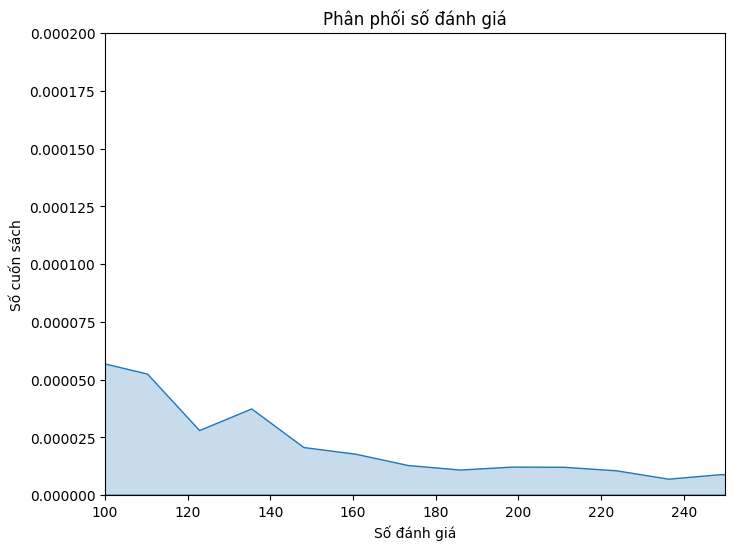

In [69]:
# Biểu đồ phân phối số đánh giá
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.kdeplot(df_ratings_count['n_ratings'], shade=True)
plt.xlabel('Số đánh giá')
plt.ylabel('Số cuốn sách')
plt.title('Phân phối số đánh giá')
plt.xlim(100, 250)
plt.ylim(0, 0.0002)
plt.show()

In [70]:
df_ratings_avg = df_ratings_books.groupby('Book-Title')['Book-Rating'].mean().reset_index()
df_ratings_avg.rename(columns={'Book-Rating':'avg_rating'}, inplace=True)
df_ratings_avg.head()

,Book-Title,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,2.25
1,Always Have Popsicles,0.00
2,Apple Magic (The Collector's series),0.00
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.00
4,Beyond IBM: Leadership Marketing and Finance ...,0.00


In [71]:
df_ratings_total = pd.merge(df_ratings_count, df_ratings_avg, on='Book-Title')
df_ratings_total.head()

,Book-Title,n_ratings,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.25
1,Always Have Popsicles,1,0.00
2,Apple Magic (The Collector's series),1,0.00
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.00
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.00


/tmp/ipykernel_732/3749471180.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_ratings_total['avg_rating'], shade=True)


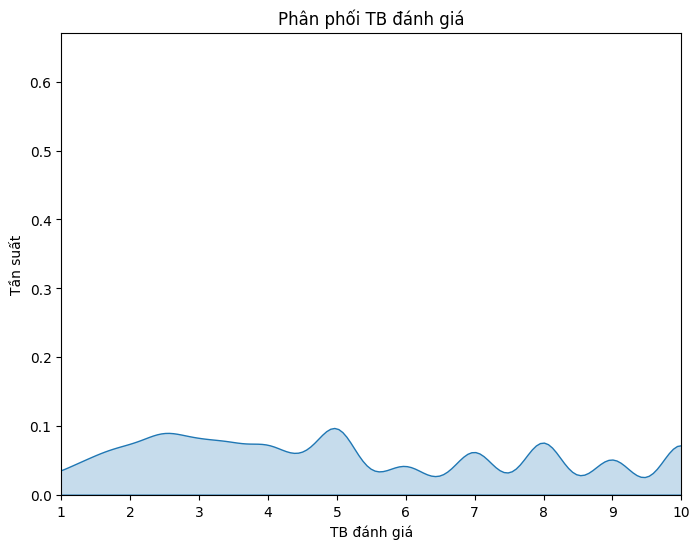

In [72]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.kdeplot(df_ratings_total['avg_rating'], shade=True)
plt.xlabel('TB đánh giá')
plt.ylabel('Tần suất')
plt.title('Phân phối TB đánh giá')
plt.xlim(1, 10)
plt.show()

In [73]:
min_rating_count = 100
df_popular_ratings = df_ratings_total[df_ratings_total['n_ratings'] >= min_rating_count]
df_popular_ratings.head()

,Book-Title,n_ratings,avg_rating
764,1984,284,4.454225
818,1st to Die: A Novel,509,3.575639
1002,24 Hours,106,2.424528
1048,2nd Chance,356,3.269663
1266,4 Blondes,151,1.947020


In [74]:
df_popular_ratings_sorted = df_popular_ratings.sort_values(by='n_ratings', ascending=False)
df_popular_ratings_sorted.head()

,Book-Title,n_ratings,avg_rating
234945,Wild Animus,2502,1.019584
196321,The Lovely Bones: A Novel,1295,4.468726
183568,The Da Vinci Code,898,4.642539
5303,A Painted House,838,3.231504
199232,The Nanny Diaries: A Novel,828,3.530193


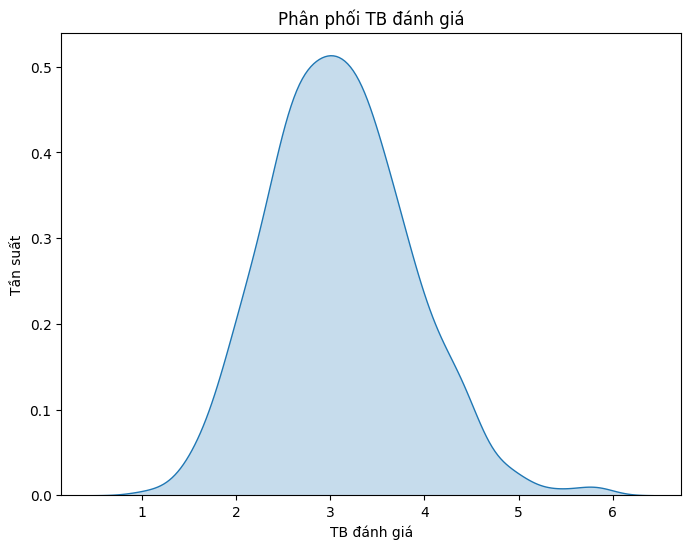

In [75]:
plt.figure(figsize=(8, 6))
sns.kdeplot(df_popular_ratings_sorted['avg_rating'], fill=True)
plt.xlabel('TB đánh giá')
plt.ylabel('Tần suất')
plt.title('Phân phối TB đánh giá')
plt.show()

In [76]:
df_popular_ratings = df_popular_ratings.merge(df_books, on='Book-Title')
df_popular_ratings.head()

,Book-Title,n_ratings,avg_rating,ISBN,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,1984,284,4.454225,0451524934,George Orwell,1990,Signet Book,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...
1,1984,284,4.454225,0451519841,George Orwell,1980,New Amer Library,http://images.amazon.com/images/P/0451519841.0...,http://images.amazon.com/images/P/0451519841.0...,http://images.amazon.com/images/P/0451519841.0...
2,1984,284,4.454225,0452262933,George Orwell,1983,Plume Books,http://images.amazon.com/images/P/0452262933.0...,http://images.amazon.com/images/P/0452262933.0...,http://images.amazon.com/images/P/0452262933.0...
3,1984,284,4.454225,0151660387,George Orwell,1983,Harcourt,http://images.amazon.com/images/P/0151660387.0...,http://images.amazon.com/images/P/0151660387.0...,http://images.amazon.com/images/P/0151660387.0...
4,1984,284,4.454225,848328006X,George Orwell,1997,"Plaza &amp; Janes Editores, S.A.",http://images.amazon.com/images/P/848328006X.0...,http://images.amazon.com/images/P/848328006X.0...,http://images.amazon.com/images/P/848328006X.0...


In [77]:
df_popular_ratings = df_popular_ratings.drop_duplicates('Book-Title')[['Book-Title', 'Book-Author', 'Image-URL-M', 'n_ratings', 'avg_rating']]
df_popular_ratings.head()

,Book-Title,Book-Author,Image-URL-M,n_ratings,avg_rating
0,1984,George Orwell,http://images.amazon.com/images/P/0451524934.0...,284,4.454225
9,1st to Die: A Novel,James Patterson,http://images.amazon.com/images/P/0446610038.0...,509,3.575639
11,24 Hours,Greg Iles,http://images.amazon.com/images/P/0451203593.0...,106,2.424528
14,2nd Chance,James Patterson,http://images.amazon.com/images/P/0316693200.0...,356,3.269663
18,4 Blondes,Candace Bushnell,http://images.amazon.com/images/P/0451203895.0...,151,1.947020


In [78]:
df_popular_ratings = df_popular_ratings.drop(columns=['Image-URL-M'])
df_popular_ratings.head()

,Book-Title,Book-Author,n_ratings,avg_rating
0,1984,George Orwell,284,4.454225
9,1st to Die: A Novel,James Patterson,509,3.575639
11,24 Hours,Greg Iles,106,2.424528
14,2nd Chance,James Patterson,356,3.269663
18,4 Blondes,Candace Bushnell,151,1.947020


In [79]:
df_popular_ratings.describe()

,n_ratings,avg_rating
count,914.000000,914.000000
mean,201.092998,3.098479
std,145.079081,0.749287
min,100.000000,1.019584
25%,121.250000,2.577224
50%,157.000000,3.056040
75%,225.750000,3.578054
max,2502.000000,5.852804


In [80]:
print([df_ratings.groupby('User-ID').count()['Book-Rating'].min(),
    df_ratings.groupby('User-ID').count()['Book-Rating'].max(),
    df_ratings.groupby('User-ID').count()['Book-Rating'].mean()])

[1, 13602, np.float64(10.920851419507423)]


In [81]:
min_user_ratings = 100
df_active_users = df_ratings.groupby('User-ID').count()['Book-Rating'].reset_index()
df_active_users = df_active_users[df_active_users['Book-Rating'] >= min_user_ratings]
df_active_users.head()

,User-ID,Book-Rating
68,183,136
95,254,314
177,507,131
294,882,126
490,1424,137


In [82]:
df_active_users_sorted = df_active_users.sort_values(by='Book-Rating', ascending=False)
df_active_users_sorted.head()

,User-ID,Book-Rating
4213,11676,13602
74815,198711,7550
58113,153662,6109
37356,98391,5891
13576,35859,5850


In [83]:
df_active_rating = df_ratings_books[df_ratings_books['User-ID'].isin(df_active_users['User-ID'])]
df_active_rating.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
298,276925,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...
299,276925,0060520507,0,"Sushi for Beginners : A Novel (Keyes, Marian)",Marian Keyes,2003,William Morrow,http://images.amazon.com/images/P/0060520507.0...,http://images.amazon.com/images/P/0060520507.0...,http://images.amazon.com/images/P/0060520507.0...
300,276925,0060930934,0,Wasted : A Memoir of Anorexia and Bulimia,Marya Hornbacher,1999,Perennial,http://images.amazon.com/images/P/0060930934.0...,http://images.amazon.com/images/P/0060930934.0...,http://images.amazon.com/images/P/0060930934.0...
301,276925,0060951303,0,La casa de los espÃ­ritus,Isabel Allende,1995,Rayo,http://images.amazon.com/images/P/0060951303.0...,http://images.amazon.com/images/P/0060951303.0...,http://images.amazon.com/images/P/0060951303.0...
302,276925,0140154078,6,The Music of Chance,Paul Auster,1993,Penguin Books,http://images.amazon.com/images/P/0140154078.0...,http://images.amazon.com/images/P/0140154078.0...,http://images.amazon.com/images/P/0140154078.0...


In [84]:
df_active_popular = df_active_rating[df_active_rating['Book-Title'].isin(df_popular_ratings['Book-Title'])]
df_active_popular.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
298,276925,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...
303,276925,0140327592,0,Matilda,Roald Dahl,1990,Viking Penguin Inc,http://images.amazon.com/images/P/0140327592.0...,http://images.amazon.com/images/P/0140327592.0...,http://images.amazon.com/images/P/0140327592.0...
310,276925,0316666343,0,The Lovely Bones: A Novel,Alice Sebold,2002,"Little, Brown",http://images.amazon.com/images/P/0316666343.0...,http://images.amazon.com/images/P/0316666343.0...,http://images.amazon.com/images/P/0316666343.0...
313,276925,0385504209,8,The Da Vinci Code,Dan Brown,2003,Doubleday,http://images.amazon.com/images/P/0385504209.0...,http://images.amazon.com/images/P/0385504209.0...,http://images.amazon.com/images/P/0385504209.0...
335,276925,0804106304,0,The Joy Luck Club,Amy Tan,1994,Prentice Hall (K-12),http://images.amazon.com/images/P/0804106304.0...,http://images.amazon.com/images/P/0804106304.0...,http://images.amazon.com/images/P/0804106304.0...


In [85]:
df_active_popular.shape

(89800, 10)

In [86]:
df_active_popular = df_active_popular.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'])
df_active_popular.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
298,276925,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc
303,276925,0140327592,0,Matilda,Roald Dahl,1990,Viking Penguin Inc
310,276925,0316666343,0,The Lovely Bones: A Novel,Alice Sebold,2002,"Little, Brown"
313,276925,0385504209,8,The Da Vinci Code,Dan Brown,2003,Doubleday
335,276925,0804106304,0,The Joy Luck Club,Amy Tan,1994,Prentice Hall (K-12)


In [87]:
pivot_table = df_active_popular.pivot_table(index='Book-Title', columns='User-ID', values='Book-Rating')
#pivot_table.fillna(0, inplace=True)
pivot_table.head()

User-ID,183,254,507,882,1424,1435,1733,1903,2033,2110,...,276018,276463,276680,276925,277427,277478,277639,278137,278188,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1st to Die: A Novel,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24 Hours,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN
2nd Chance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4 Blondes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
pivot_table.fillna(0, inplace=True)
from sklearn.metrics.pairwise import cosine_similarity
similarity_scores = cosine_similarity(pivot_table)
print(similarity_scores.shape)
print(similarity_scores[:4])

(914, 914)
[[1.         0.06200563 0.00929535 ... 0.07216303 0.05555583 0.02896328]
 [0.06200563 1.         0.07131015 ... 0.04692566 0.13413489 0.12264662]
 [0.00929535 0.07131015 1.         ... 0.02856084 0.04972988 0.01222063]
 [0.00760079 0.24207864 0.07695984 ... 0.02958193 0.04066404 0.07889543]]


In [98]:
def get_similar_books(book_name, top_k):
    book_index = pivot_table.index.get_loc(book_name)
    # vector độ tương đồng
    book_similarities = similarity_scores[book_index]
    book_similarities_sorted = sorted(list(enumerate(book_similarities)), key=lambda x: x[1], reverse=True)

    # Lấy top k quyển có độ tương đồng với 1984
    for i in range(1, top_k + 1):
        book_title = pivot_table.index[book_similarities_sorted[i][0]]
        book_similarity = book_similarities_sorted[i][1]
        print(f"{i}. {book_title}, similarity: {book_similarity}")

get_similar_books('1984', 5)

1. Animal Farm, similarity: 0.24031923928464405
2. Brave New World, similarity: 0.2270061834031283
3. Slaughterhouse Five or the Children's Crusade: A Duty Dance With Death, similarity: 0.19040609890525767
4. Timeline, similarity: 0.18937432170873128
5. The Handmaid's Tale, similarity: 0.1707850688171492


In [94]:
get_similar_books('The Da Vinci Code')

1. Angels &amp; Demons, similarity: 0.2718922777381662
2. Middlesex: A Novel, similarity: 0.1999046211198602
3. The Lovely Bones: A Novel, similarity: 0.1905762014195807
4. Deception Point, similarity: 0.1894149366910935
5. The Blue Nowhere : A Novel, similarity: 0.1874419951419556


In [99]:
get_similar_books('Harry Potter and the Prisoner of Azkaban (Book 3)', 10)

1. Harry Potter and the Goblet of Fire (Book 4), similarity: 0.6575878416851263
2. Harry Potter and the Chamber of Secrets (Book 2), similarity: 0.6073779045442149
3. Harry Potter and the Order of the Phoenix (Book 5), similarity: 0.4625553092509845
4. Harry Potter and the Sorcerer's Stone (Book 1), similarity: 0.44855275184407134
5. Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)), similarity: 0.3540146558864145
6. The Fellowship of the Ring (The Lord of the Rings, Part 1), similarity: 0.23133841285978585
7. Charlotte's Web (Trophy Newbery), similarity: 0.193406895732013
8. The Shelters of Stone (Earth's Children Series, No 5), similarity: 0.16576837263588645
9. Bridget Jones's Diary, similarity: 0.16363813398966748
10. The Two Towers (The Lord of the Rings, Part 2), similarity: 0.16276385253945982
